In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data=pd.read_csv("Mall_Customers.csv")
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [15]:
data=pd.get_dummies(data,drop_first=True).astype(int)
data

X=data.iloc[:, [3,4]].values


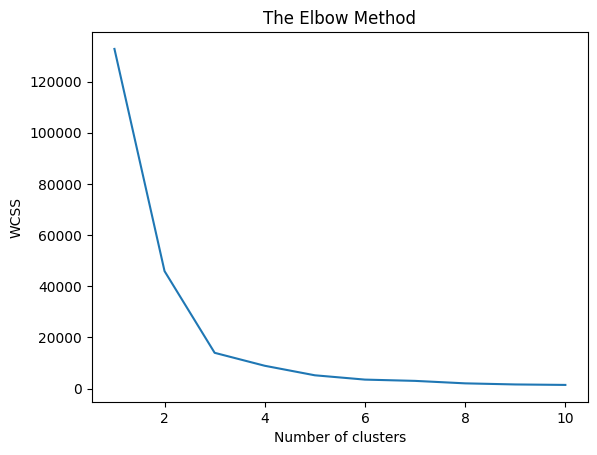

In [17]:
from sklearn.cluster import KMeans
list1 = []
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(X)
  list1.append(kmeans.inertia_)
plt.plot(range(1,11),list1)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [20]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(X)
y_kmeans

array([2, 4, 3, 4, 2, 4, 3, 1, 3, 4, 3, 1, 3, 4, 3, 4, 2, 4, 2, 1, 2, 4,
       3, 4, 3, 4, 2, 0, 2, 1, 3, 4, 3, 1, 3, 4, 3, 4, 2, 4, 2, 1, 2, 0,
       2, 4, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0,
       0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 1, 2, 4, 2, 1, 3, 4, 3, 4,
       2, 4, 3, 1, 3, 4, 3, 4, 3, 1, 2, 1, 3, 1, 2, 4, 3, 1, 3, 1, 3, 4,
       3, 1, 3, 4, 3, 4, 2, 1, 3, 1, 2, 4, 3, 1, 2, 0, 3, 4, 3, 1, 3, 1,
       3, 4, 3, 1, 2, 1, 3, 1, 2, 1, 3, 4, 3, 1, 3, 4, 3, 1, 3, 4, 2, 4,
       3, 1], dtype=int32)

In [22]:
supervised=pd.DataFrame(data)

In [23]:
supervised['Cluster_group']=y_kmeans


In [25]:
supervised

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,Cluster_group
0,1,19,15,39,1,2
1,2,21,15,81,1,4
2,3,20,16,6,0,3
3,4,23,16,77,0,4
4,5,31,17,40,0,2
...,...,...,...,...,...,...
195,196,35,120,79,0,4
196,197,45,126,28,0,2
197,198,32,126,74,1,4
198,199,32,137,18,1,3


In [27]:
supervised.to_csv("cluster.csv",index=False)

In [28]:
centroid=kmeans.cluster_centers_
centroid


array([[52.79032258,  0.46774194],
       [90.7037037 ,  0.44444444],
       [37.        ,  0.3       ],
       [11.84615385,  0.56410256],
       [74.25      ,  0.40625   ]])

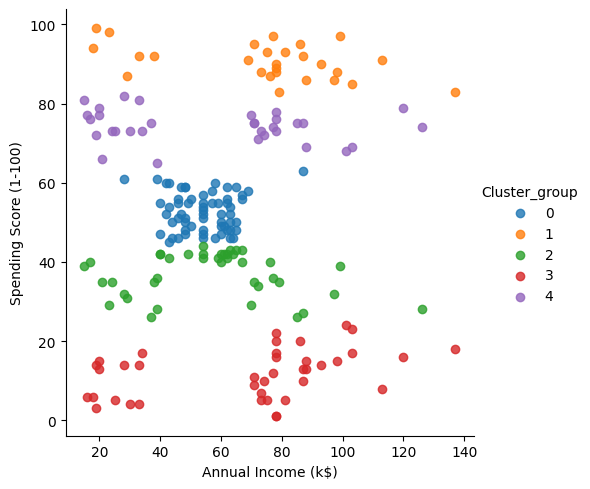

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=supervised,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster_group',
    fit_reg=False,
    legend=True
)

plt.show()